In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = sns.load_dataset('penguins').dropna()
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [3]:
df['species'].value_counts()

,count
species,
Adelie,146
Gentoo,119
Chinstrap,68


In [4]:
df_adelie = df[df['species'] == 'Adelie']
df_adelie

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
147,Adelie,Dream,36.6,18.4,184.0,3475.0,Female
148,Adelie,Dream,36.0,17.8,195.0,3450.0,Female
149,Adelie,Dream,37.8,18.1,193.0,3750.0,Male
150,Adelie,Dream,36.0,17.1,187.0,3700.0,Female


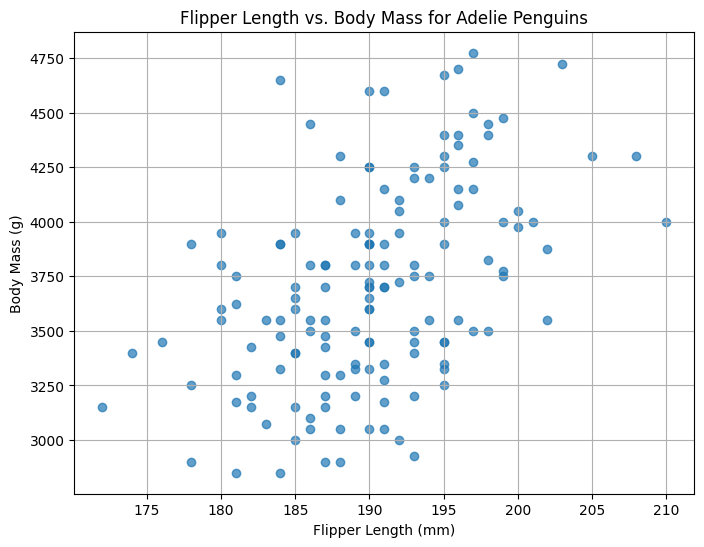

In [5]:
plt.figure(figsize=(8, 6))
plt.scatter(df_adelie['flipper_length_mm'], df_adelie['body_mass_g'], alpha=0.7)
plt.xlabel('Flipper Length (mm)')
plt.ylabel('Body Mass (g)')
plt.title('Flipper Length vs. Body Mass for Adelie Penguins')
plt.grid(True)
plt.show()

In [6]:
X = df[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm']]
y = df['body_mass_g'].values.reshape(-1,1)

# CREAMOS RED NEURONAL PARA PREDECIR EL PESO DE PINGUINO

## PASO 1 - IMPORTAMOS LIBRERIAS NECESARIAS

In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import Input

## PASO 2 - ESCALAMOS DATOS

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
y_scaled = scaler.fit_transform(y)

## PASO 3 - DIVIDAMOS DATASET EN ENTRENAMIENTO Y PRUEBA

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

## PASO 4 - CREAMOS LA RED NEURONAL

In [10]:
red = Sequential()
inputs = Input(shape=(3,))
entrada = Dense(units=64,activation='relu')
oculta1 = Dense(units=64,activation='relu')
oculta2 = Dense(units=32,activation='relu')
salida = Dense(units=1,activation='relu')

red.add(entrada)
red.add(oculta1)
red.add(Dropout(0.5))
red.add(oculta2)
red.add(salida)

red

<Sequential name=sequential, built=False>

## PASO 5- COMPILAMOS LA RED

In [11]:
red.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mse']
)

## PASO 6 - ENTRENAMOS LA RED NEURONAL

In [12]:
#1) Callbacks: parar cuando no mejora y guardar el mejor modelo
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,               # cuántas épocas esperar sin mejora
    restore_best_weights=True # vuelve al mejor punto automáticamente
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_model.keras",
    monitor="val_loss",
    save_best_only=True
)

In [13]:
history = red.fit(X_train,y_train,epochs=20,batch_size=128,validation_split=0.2,validation_data=(X_test,y_test))

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 979ms/step - loss: 0.9603 - mse: 0.9603 - val_loss: 0.8044 - val_mse: 0.8044
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.8239 - mse: 0.8239 - val_loss: 0.7292 - val_mse: 0.7292
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.7451 - mse: 0.7451 - val_loss: 0.6596 - val_mse: 0.6596
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.6667 - mse: 0.6667 - val_loss: 0.6014 - val_mse: 0.6014
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.6265 - mse: 0.6265 - val_loss: 0.5611 - val_mse: 0.5611
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.5814 - mse: 0.5814 - val_loss: 0.5349 - val_mse: 0.5349
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.6154 - mse: 0.6154 - val_loss: 0.5174 - val_mse: 0.5174
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.5801 - mse: 0.5801 - val_loss: 0.5062 - val_mse: 0.5062
Epoch 9/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.5692 - mse: 0.5692 -

In [14]:
loss, mae = red.evaluate(X_test, y_test, verbose=0)
print(f'loss evaluate : {loss}')
print(f' mae evaluate : {mae}')

loss evaluate : 0.48004093766212463
 mae evaluate : 0.48004093766212463


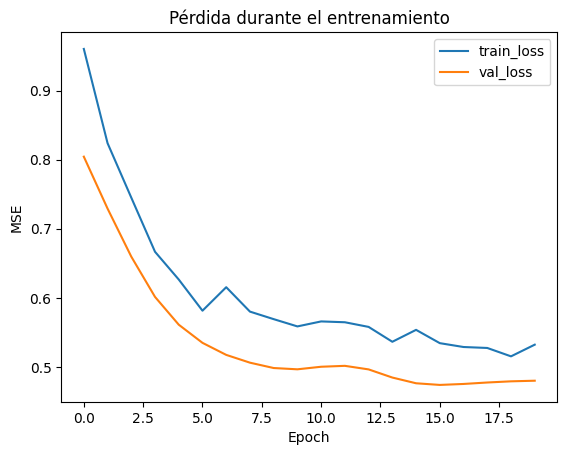

In [15]:
# 📈 Gráfico de pérdida
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.title('Pérdida durante el entrenamiento')
plt.show()